#   Regularisation Preview: Preventing Overfitting & Building Robust Models with Ridge, Lasso & When to Use Each

**Dataset:** Customer Churn Prediction Data (Financial Services)

---

##  Objectives of the notebook

By the end of this notebook, you will be able to:

1. **Understand overfitting** and why it's a critical problem in business models
2. **Apply Ridge and Lasso regression** to build more robust predictive models  
3. **Choose the right regularization technique** based on your business problem
4. **Interpret regularized models** and communicate trade-offs to stakeholders

---

## 🏢 Business Context

**Scenario:** You're a data scientist at a financial services company. The marketing team wants to:
- Predict which customers are likely to churn (leave the company)
- Identify the most important factors driving churn
- Build a model that works well on NEW customers, not just historical data
- Avoid false confidence from models that "memorize" rather than "learn"

**Your Task:** Build regularized regression models that generalize well to future customers.

**The Challenge:** You have 50+ features (customer demographics, transaction history, engagement metrics) but only 1,000 customers. Classic overfitting territory!

---


# Section 0: Understanding Regularization

## 0.1 The Overfitting Problem: A Business Story

### The Core Question:
**"Why does my model perform amazingly on historical data but fails miserably on new customers?"**

### 📖 Real-World Analogy: The Job Interview

Imagine you're hiring a new employee:

**Candidate A (The Memorizer):**
- Memorized answers to 100 common interview questions
- Performs perfectly when you ask those exact questions
- Completely lost when you ask a slightly different question
- **This is OVERFITTING** 🚫

**Candidate B (The Problem Solver):**
- Understands core principles and concepts
- Can handle variations and new situations
- Slightly less perfect on memorized questions
- But adapts well to real-world challenges
- **This is REGULARIZATION** ✅

### 💡 In Machine Learning Terms:

**Overfitting occurs when your model:**
1. Learns the "noise" in your training data (random patterns that don't generalize)
2. Becomes too complex for the amount of data you have
3. Performs great on historical data but poorly on new data
4. Makes business decisions based on coincidences, not real patterns

**Example:**
Your model notices that 3 customers who churned all had birthdays in March. It starts predicting that ALL March-birthday customers will churn. This is clearly nonsense, but without regularization, the model will latch onto such patterns!

---

## 0.2 What is Regularization? (The Simple Explanation)

###   The Core Idea:
**Regularization adds a "penalty" for model complexity to prevent overfitting.**

Think of it like this:

### 🏃 The Athletic Training Analogy:

**Without Regularization:**
- Like training ONLY for one specific race course
- You memorize every turn, every hill
- You're amazing on THAT course
- But terrible on any other course

**With Regularization:**
- Like training for general athletic fitness
- You might not be #1 on any specific course
- But you perform consistently well on ALL courses
- You're a reliable, robust athlete

### 📊 In Mathematical Terms:

**Traditional Linear Regression:**
```
Minimize: Prediction Error
```

**Regularized Regression:**
```
Minimize: Prediction Error + Penalty for Complexity
```

The "Penalty for Complexity" forces the model to:
- Keep coefficients small
- Focus on the most important features
- Ignore noise and random patterns

### 💼 Business Translation:

**Regularization helps you build models that:**
1. Work well on future customers, not just past ones
2. Focus on truly important factors
3. Are more interpretable and trustworthy
4. Require less data to be effective

---

## 0.3 Ridge vs Lasso: The Two Main Types

### 🔵 Ridge Regression (L2 Regularization)

**What it does:**
- Shrinks ALL coefficients toward zero
- Keeps ALL features in the model
- Makes coefficients smaller and more stable

**Penalty Formula:**
```
Penalty = α × (Sum of squared coefficients)
```

**The Kitchen Analogy:**
Imagine you're making a smoothie with 20 ingredients:
- **Ridge says:** "Use all 20 ingredients, but reduce each portion"
- Each ingredient contributes a little bit
- No ingredient dominates
- Balanced, smooth flavor

**Business Use Case:**
- You believe MANY factors influence the outcome
- All features have some relevance
- You want to reduce noise, not remove features
- Example: Customer satisfaction depends on many touchpoints

### 🔴 Lasso Regression (L1 Regularization)

**What it does:**
- Shrinks some coefficients ALL THE WAY to exactly zero
- Performs automatic feature selection
- Creates simpler, more interpretable models

**Penalty Formula:**
```
Penalty = α × (Sum of absolute coefficients)
```

**The Kitchen Analogy:**
Same smoothie with 20 ingredients:
- **Lasso says:** "Only use the 5 most important ingredients, discard the rest"
- Clear, dominant flavors
- Simpler recipe
- Easier to explain

**Business Use Case:**
- You have MANY features, but only a few matter
- You need to identify the key drivers
- You want a simple, interpretable model
- Example: Which of 100 marketing channels actually drive sales?

### 📊 Quick Comparison:

| Aspect | Ridge (L2) | Lasso (L1) |
|--------|-----------|------------|
| **Keeps all features?** | ✅ Yes | ❌ No (automatic selection) |
| **Coefficients** | Shrinks toward 0 | Sets many to exactly 0 |
| **Best for** | Multicollinearity | Feature selection |
| **Interpretability** | Moderate | High (fewer features) |
| **When many features matter** | ✅ | ❌ |
| **When few features matter** | ❌ | ✅ |

---

## 0.4 The Regularization Parameter (α / Alpha)

### 🎛️ The Control Knob:

**Alpha (α)** controls how much penalty you apply:

**α = 0:**
- No regularization
- Regular linear regression
- High risk of overfitting
-   Memorizer mode

**α = Small (e.g., 0.1):**
- Light regularization
- Slight reduction in overfitting
- Still fairly complex model
-   Mostly memorizer

**α = Medium (e.g., 1.0):**
- Moderate regularization
- Good balance
- **Often the sweet spot**
-   Balanced learner

**α = Large (e.g., 100):**
- Heavy regularization
- Very simple model
- Risk of underfitting
-   Too general

**α = ∞:**
- All coefficients → 0
- Model predicts the average
- Useless
-   No learning

### 🔍 How to Choose Alpha?

**Cross-Validation!**
- Try many alpha values
- Test on held-out data
- Pick the alpha with best validation performance
- We'll code this later!

### 💼 Business Intuition:

**Small α:** Trust your data more (works when you have LOTS of data)  
**Large α:** Trust general patterns more (works when you have LITTLE data)

---


# Section 1: Setup & The Overfitting Problem (20 min)

## 1.1 Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('rocket')

# Random seed for reproducibility
np.random.seed(42)

print("✅ All libraries loaded successfully!")
print(f"📦 NumPy version: {np.__version__}")
print(f"📦 Pandas version: {pd.__version__}")

✅ All libraries loaded successfully!
📦 NumPy version: 2.1.3
📦 Pandas version: 2.2.3


## 1.2 Load Business Dataset

### 📊 Dataset: Customer Churn Prediction

**Business Context:**
- 1,000 customers from a financial services company
- 50 features (demographics, behavior, engagement, etc.)
- Target: Churn_Score (0-100, higher = more likely to leave)

**Dataset Details:**
- **Demographics:** Age, Income, Education_Level, Employment_Years, Dependents
- **Account Info:** Account_Age_Months, Account_Balance, Credit_Score, Loan_Amount, Investment_Portfolio
- **Transactions:** Monthly_Transactions, Avg_Transaction_Size, Online_Transactions_Pct, ATM_Usage, Bill_Payments
- **Engagement:** App_Logins_Month, Customer_Service_Calls, Branch_Visits, Email_Clicks, Survey_Responses
- **Products:** Num_Products, Credit_Card, Savings_Account, Checking_Account, Mortgage
- **Behavior:** Late_Payments, Overdraft_Frequency, Balance_Inquiry_Freq, Statement_Delivery, Autopay_Enabled

**This is a HIGH-DIMENSIONAL problem:**
- Many features relative to samples
- Perfect scenario for demonstrating overfitting
- Regularization will be crucial!

In [2]:
#  Load the dataset
df = pd.read_csv('dataset/customer_churn_data.csv')

# Quick overview
print("✅ Dataset loaded successfully!")
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"   - Samples: {len(df)}")
print(f"   - Features (Excluding target): {len(df.columns) - 1}")  # Excluding target
print(f"   - Target: Churn_Score")

# Display first few rows
print(f"\n📋 First Few Rows:")
print(df.head())

# Basic statistics
print(f"\n📈 Dataset Summary:")
print(f"   - Missing values: {df.isnull().sum().sum()}")
print(f"   - Churn Score range: {df['Churn_Score'].min():.2f} - {df['Churn_Score'].max():.2f}")
print(f"   - Churn Score mean: {df['Churn_Score'].mean():.2f}")
print(f"   - Churn Score std: {df['Churn_Score'].std():.2f}")

# Feature categories
print(f"\n📊 Sample Features:")
print(f"   Demographics: Age, Income, Education_Level, ...")
print(f"   Account: Account_Balance, Credit_Score, ...")
print(f"   Transactions: Monthly_Transactions, Avg_Transaction_Size, ...")
print(f"   Engagement: App_Logins_Month, Customer_Service_Calls, ...")
print(f"   Products: Num_Products, Credit_Card, ...")
print(f"   Behavior: Late_Payments, Overdraft_Frequency, ...")

print(f"\n⚠️ This is a HIGH-DIMENSIONAL problem!")
print(f"   Ratio of Features to Samples: {(len(df.columns)-1)/len(df):.1%}")


✅ Dataset loaded successfully!

📊 Dataset Shape: (400, 101)
   - Samples: 400
   - Features (Excluding target): 100
   - Target: Churn_Score

📋 First Few Rows:
        Age    Income  Education_Level  Employment_Years  Dependents  \
0  0.766718  0.654278        -0.574753         -0.883217    1.469344   
1  0.640582  0.868724        -1.682098         -2.045752    0.251422   
2 -1.192937 -1.364249        -0.032969          0.197458    1.056299   
3 -0.519345 -0.448258        -0.376915         -0.565967   -0.643488   
4 -0.060868 -0.586326         0.402165          0.359146   -0.232955   

   Account_Age_Months  Account_Balance  Credit_Score  Loan_Amount  \
0            1.330181        -1.375940     -1.045567     0.255659   
1            0.153458         1.806392      1.653001    -2.282120   
2            1.490668         0.421563      0.266491    -0.339131   
3           -0.883648         0.354177      0.577481     0.227148   
4           -0.456021        -0.553646     -0.134532    -0.221

### Rule of thumb in ML:

  - Low-dimensional: Feature-to-sample ratio < 1% (e.g., 5 features, 1000 samples = 0.5%)

  - Moderately high-dimensional: 1-10%

  - High-dimensional: 10-50% (e.g., 100 features, 1000 samples = 10%), (your case: 25%)

  - Ultra high-dimensional: >50% (e.g., 600 features, 1000 samples = 60%)

## 1.3 Demonstrate Overfitting with Regular Linear Regression

###   Goal:
Show how a regular linear regression overfits when we have many features.

### 📊 What We'll Do:
1. Split data into train/test sets
2. Fit a regular linear regression (no regularization)
3. Compare training vs test performance
4. Observe the overfitting problem!


In [3]:
# Prepare data
X = df.drop('Churn_Score', axis=1)
y = df['Churn_Score']

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42)

# Scale features (important for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data prepared for modeling")
print(f"\n📊 Train Set: {X_train.shape}")
print(f"📊 Test Set: {X_test.shape}")

✅ Data prepared for modeling

📊 Train Set: (280, 100)
📊 Test Set: (120, 100)


In [4]:
# Fit regular linear regression (NO regularization)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("="*70)
print("🔴 REGULAR LINEAR REGRESSION (NO REGULARIZATION)")
print("="*70)
print(f"\n📈 TRAINING Performance:")
print(f"   R² Score: {train_r2:.4f}")
print(f"   RMSE: {train_rmse:.4f}")
print(f"\n📉 TESTING Performance:")
print(f"   R² Score: {test_r2:.4f}")
print(f"   RMSE: {test_rmse:.4f}")
print(f"\n⚠️ OVERFITTING CHECK:")
print(f"   R² Gap: {train_r2 - test_r2:.4f}")
print(f"   RMSE Gap: {test_rmse - train_rmse:.4f}")

if (train_r2 - test_r2) > 0.1:
    print(f"\n🚨 OVERFITTING DETECTED!")
    print(f"   The model performs {train_r2 - test_r2:.1%} better on training data.")
    print(f"   This model is 'memorizing' rather than 'learning'.")
else:
    print(f"\n✅ No significant overfitting")

🔴 REGULAR LINEAR REGRESSION (NO REGULARIZATION)

📈 TRAINING Performance:
   R² Score: 0.7971
   RMSE: 7.2878

📉 TESTING Performance:
   R² Score: 0.5187
   RMSE: 10.9578

⚠️ OVERFITTING CHECK:
   R² Gap: 0.2784
   RMSE Gap: 3.6700

🚨 OVERFITTING DETECTED!
   The model performs 27.8% better on training data.
   This model is 'memorizing' rather than 'learning'.


# Section 2: Ridge Regression (L2 Regularization)

Ridge Regression is a regularization technique used in linear regression to reduce overfitting and improve model stability.
It works by adding an L2 penalty to the loss function, which shrinks large coefficients toward zero

## 2.1 Understanding Ridge: The Math Behind It


###The Ridge Objective Function:

**Regular Linear Regression:**
```
Minimize: Sum of Squared Errors (SSE)
```

**Ridge Regression:**
```
Minimize: SSE + α × (Sum of Squared Coefficients)
          ↑         ↑
     Fit Data    Penalty
```

### 💡 What This Means:

Ridge forces the model to:
1. **Still fit the data well** (minimize prediction errors)
2. **But keep coefficients small** (the penalty term)

###   Ridge Characteristics:

✅ **Keeps ALL features** (no coefficient becomes exactly 0)  
✅ **Shrinks coefficients** toward zero  
✅ **Handles multicollinearity** (correlated features)  
✅ **More stable** than regular regression  
❌ **Doesn't do feature selection** (all features remain)

---

## 2.2 Implementing Ridge Regression

### 🔧 Step 1: Fit Ridge with a Fixed Alpha

## Alpha (α) - The Regularization Knob

| α = 0   | α = 1 | α = 100 |
|--------|-------|-------|
| No Penalty  |        Balanced    |  Strong Penalty|
| Standard Regression          | ✅ SWEET SPOT    | Nearly Flat |
| Overfitting Risk| Good   Trade-off|       Underfitting Risk|            |


In [5]:
# Start with alpha = 1.0 (moderate regularization)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate metrics
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))

print("="*70)
print("🔵 RIDGE REGRESSION (α = 1.0)")
print("="*70)
print(f"\n📈 TRAINING Performance:")
print(f"   R² Score: {train_r2_ridge:.4f}")
print(f"   RMSE: {train_rmse_ridge:.4f}")
print(f"\n📉 TESTING Performance:")
print(f"   R² Score: {test_r2_ridge:.4f}")
print(f"   RMSE: {test_rmse_ridge:.4f}")
print(f"\n✅ OVERFITTING CHECK:")
print(f"   R² Gap: {train_r2_ridge - test_r2_ridge:.4f}")
print(f"   RMSE Gap: {test_rmse_ridge - train_rmse_ridge:.4f}")

# Compare with regular regression
print(f"\n📊 IMPROVEMENT vs Regular Regression:")
print(f"   Test R² Improvement: {test_r2_ridge - test_r2:+.4f}")
print(f"   Test RMSE Improvement: {test_rmse - test_rmse_ridge:+.4f}")
print(f"   Overfitting Reduction: {(train_r2 - test_r2) - (train_r2_ridge - test_r2_ridge):.4f}")


🔵 RIDGE REGRESSION (α = 1.0)

📈 TRAINING Performance:
   R² Score: 0.7969
   RMSE: 7.2919

📉 TESTING Performance:
   R² Score: 0.5228
   RMSE: 10.9109

✅ OVERFITTING CHECK:
   R² Gap: 0.2741
   RMSE Gap: 3.6190

📊 IMPROVEMENT vs Regular Regression:
   Test R² Improvement: +0.0041
   Test RMSE Improvement: +0.0469
   Overfitting Reduction: 0.0043


# Section 3: Lasso Regression (L1 Regularization)

Lasso Regression is a regularization technique used in linear regression to reduce overfitting and perform feature selection.

It adds an L1 penalty to the loss function, which can shrink some coefficients exactly to zero. This means the model automatically removes less important features.

***In simple terms:***
Lasso Regression simplifies the model by keeping only the most important predictors, making it easier to interpret and often improving performance when many features are irrelevant.

## 3.1 Understanding Lasso: The Math Behind It

### 📐 The Lasso Objective Function:

**Lasso Regression:**
```
Minimize: SSE + α × (Sum of Absolute Coefficients)
          ↑         ↑
     Fit Data    Penalty
```

### 💡 Key Difference from Ridge:

**Ridge:** Penalizes squared coefficients (β²)  
**Lasso:** Penalizes absolute coefficients (|β|)

This small mathematical change creates a BIG practical difference!

###   Lasso Characteristics:

✅ **Performs feature selection** (sets coefficients to EXACTLY 0)  
✅ **Creates sparse models** (fewer features)  
✅ **Highly interpretable** (easy to explain)  
✅ **Works with high-dimensional data** (p >> n)  
❌ **Struggles with correlated features** (picks one, ignores others)

---

## 3.2 Implementing Lasso Regression


In [17]:
# Start with alpha = 0.1 (Lasso typically needs smaller alphas)
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate metrics
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)
train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))

# Count non-zero coefficients
n_nonzero = np.sum(lasso_model.coef_ != 0)
n_features = X_train.shape[1] # Selects axis = 1, which are the columns(features)

print("="*70)
print("🔴 LASSO REGRESSION (α = 0.1)")
print("="*70)
print(f"\n📈 TRAINING Performance:")
print(f"   R² Score: {train_r2_lasso:.4f}")
print(f"   RMSE: {train_rmse_lasso:.4f}")
print(f"\n📉 TESTING Performance:")
print(f"   R² Score: {test_r2_lasso:.4f}")
print(f"   RMSE: {test_rmse_lasso:.4f}")
print(f"\n✂️ FEATURE SELECTION:")
print(f"   Features selected: {n_nonzero} out of {n_features}")
print(f"   Features eliminated: {n_features - n_nonzero}")
print(f"   Sparsity: {(1 - n_nonzero/n_features)*100:.1f}%")

🔴 LASSO REGRESSION (α = 0.1)

📈 TRAINING Performance:
   R² Score: 0.7865
   RMSE: 7.4764

📉 TESTING Performance:
   R² Score: 0.5977
   RMSE: 10.0177

✂️ FEATURE SELECTION:
   Features selected: 86 out of 100
   Features eliminated: 14
   Sparsity: 14.0%


# Section 4: When & Why - Decision Framework

## 4.1 The Decision Framework: When to Use What

### 🌳 Complete Decision Tree for Business Problems

```
START: Regression Problem
   │
   ├─❓ Do you have MORE FEATURES than SAMPLES? (p > n)
   │   ├─ YES → ⚠️ High-dimensional problem
   │   │         ├─ Need interpretability? → 🔴 LASSO
   │   │         └─ Don't need interpretability? → 🟣 ELASTIC NET
   │   └─ NO → Continue...
   │
   ├─❓ Are your features HIGHLY CORRELATED?
   │   ├─ YES → 🔵 RIDGE (handles multicollinearity)
   │   └─ NO → Continue...
   │
   ├─❓ Do you need AUTOMATIC FEATURE SELECTION?
   │   ├─ YES → 🔴 LASSO (sets coefficients to zero)
   │   └─ NO → Continue...
   │
   ├─❓ Do you believe MANY features contribute?
   │   ├─ YES → 🔵 RIDGE (keeps all features)
   │   └─ NO → Continue...
   │
   ├─❓ Is MODEL INTERPRETABILITY critical?
   │   ├─ YES → 🔴 LASSO (fewer features = easier to explain)
   │   └─ NO → Continue...
   │
   └─✅ DECISION MADE!
```

### 📊 Quick Reference Table:

| Scenario | Ridge (L2) | Lasso (L1) | Elastic Net |
|----------|-----------|-----------|-------------|
| Many features | ✅ | ✅✅ | ✅✅ |
| Correlated X's | ✅✅ | ⚠️ | ✅ |
| Feature select | ❌ | ✅✅ | ✅ |
| Interpretable | ⚠️ | ✅✅ | ✅ |
| Sparse model | ❌ | ✅✅ | ✅ |
| Stability | ✅✅ | ⚠️ | ✅✅ |

Legend: ✅✅ = Excellent, ✅ = Good, ⚠️ = Use with caution, ❌ = Not suitable

---


# Find Optimal Ridge Alpha (Code)

🎯 OPTIMAL ALPHA: 75.4312
   Test R² at Best: 0.5558


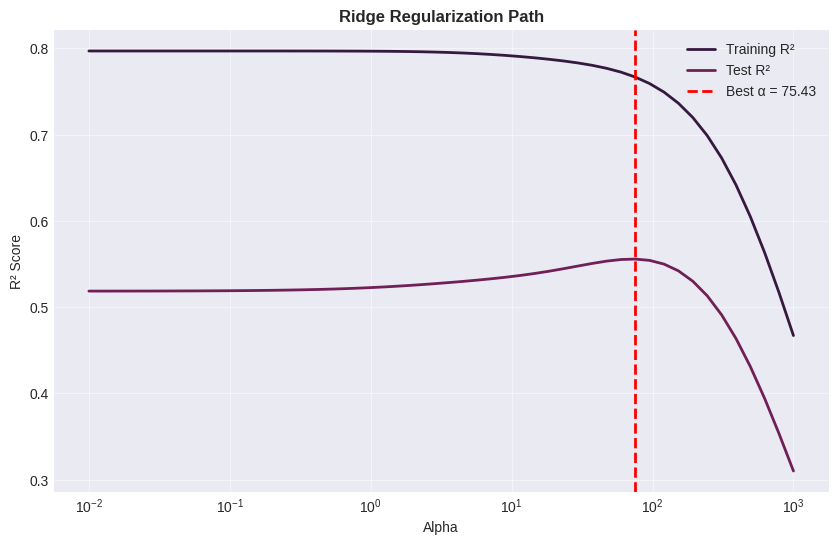

In [24]:
# Try range of alphas
alphas = np.logspace(-2, 3, 50)
train_scores = []
test_scores = []

for alpha in alphas:
  ridge_temp = Ridge(alpha=alpha)
  ridge_temp.fit(X_train_scaled, y_train)
  train_scores.append(ridge_temp.score(X_train_scaled, y_train))
  test_scores.append(ridge_temp.score(X_test_scaled, y_test))

# Best alpha
best_idx = np.argmax(test_scores)
best_alpha = alphas[best_idx]
best_score = test_scores[best_idx]

print(f"🎯 OPTIMAL ALPHA: {best_alpha:.4f}")
print(f"   Test R² at Best: {best_score:.4f}")

# Plot
plt.figure(figsize = (10, 6))
plt.plot(alphas, train_scores, label = 'Training R²', linewidth = 2)
plt.plot(alphas, test_scores, label = 'Test R²', linewidth = 2)
plt.axvline(x=best_alpha, color='red', linestyle='--', linewidth=2,
            label=f'Best α = {best_alpha:.2f}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Ridge Regularization Path', fontweight='bold')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

# Find Optimal Lasso Alpha

🎯 OPTIMAL LASSO ALPHA: 0.5179
   Test R²: 0.6961
   Features Selected: 33


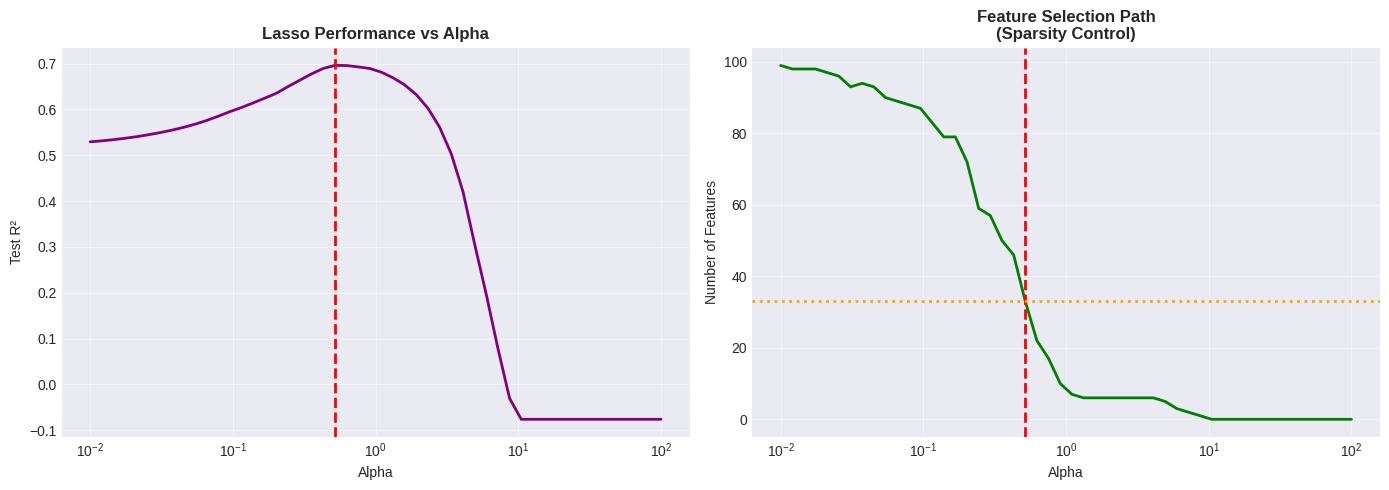

In [32]:
# Alpha search
alphas_lasso = np.logspace(-2, 2, 50)
test_scores_lasso = []
n_features_list = []

for alpha in alphas_lasso:
  lasso_temp = Lasso(alpha = alpha, max_iter = 10000)
  lasso_temp.fit(X_train_scaled, y_train)
  test_scores_lasso.append(lasso_temp.score(X_test_scaled, y_test))
  n_features_list.append(np.sum(lasso_temp.coef_ != 0))

best_idx_lasso = np.argmax(test_scores_lasso)
best_alpha_lasso = alphas_lasso[best_idx_lasso]
best_n_features = n_features_list[best_idx_lasso]

print(f"🎯 OPTIMAL LASSO ALPHA: {best_alpha_lasso:.4f}")
print(f"   Test R²: {test_scores_lasso[best_idx_lasso]:.4f}")
print(f"   Features Selected: {best_n_features}")

# Plot feature selection path
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alphas_lasso, test_scores_lasso, linewidth=2, color='purple')
axes[0].axvline(x=best_alpha_lasso, color='red', linestyle='--', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Test R²')
axes[0].set_title('Lasso Performance vs Alpha', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Test R²')
axes[0].set_title('Lasso Performance vs Alpha', fontweight='bold')
axes[0].grid(alpha=0.5)

axes[1].plot(alphas_lasso, n_features_list, linewidth=2, color='green')
axes[1].axvline(x=best_alpha_lasso, color='red', linestyle='--', linewidth=2)
axes[1].axhline(y=best_n_features, color='orange', linestyle=':', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Feature Selection Path\n(Sparsity Control)', fontweight='bold')
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.show()

# Section 5: Wrap-up & Next Steps

## 5.1 Key Takeaways


In [33]:
print("""
═══════════════════════════════════════════════════════════════════════════
                             KEY TAKEAWAYS
═══════════════════════════════════════════════════════════════════════════

1️⃣ OVERFITTING:
   • Models that memorize training data fail on new data
   • Common with many features, little data
   • Detected by large train-test performance gap

2️⃣ RIDGE REGRESSION (L2):
   • Shrinks ALL coefficients toward zero
   • Keeps ALL features in model
   • Best for multicollinearity
   • Use when many features matter

3️⃣ LASSO REGRESSION (L1):
   • Sets some coefficients to EXACTLY zero
   • Performs automatic feature selection
   • Creates sparse, interpretable models
   • Use when few features matter

4️⃣ CHOOSING THE RIGHT APPROACH:
   • High-dimensional (p > n) → Lasso or Elastic Net
   • Correlated features → Ridge
   • Need interpretability → Lasso
   • Need feature selection → Lasso
   • Not sure → Try all and compare

5️⃣ ALPHA SELECTION:
   • ALWAYS use cross-validation (RidgeCV, LassoCV)
   • Test wide range of values
   • Small α = trust data, Large α = trust simplicity

═══════════════════════════════════════════════════════════════════════════
""")



═══════════════════════════════════════════════════════════════════════════
                             KEY TAKEAWAYS
═══════════════════════════════════════════════════════════════════════════

1️⃣ OVERFITTING:
   • Models that memorize training data fail on new data
   • Common with many features, little data
   • Detected by large train-test performance gap

2️⃣ RIDGE REGRESSION (L2):
   • Shrinks ALL coefficients toward zero
   • Keeps ALL features in model
   • Best for multicollinearity
   • Use when many features matter

3️⃣ LASSO REGRESSION (L1):
   • Sets some coefficients to EXACTLY zero
   • Performs automatic feature selection
   • Creates sparse, interpretable models
   • Use when few features matter

4️⃣ CHOOSING THE RIGHT APPROACH:
   • High-dimensional (p > n) → Lasso or Elastic Net
   • Correlated features → Ridge
   • Need interpretability → Lasso
   • Need feature selection → Lasso
   • Not sure → Try all and compare

5️⃣ ALPHA SELECTION:
   • ALWAYS use cross-vali

In [35]:
print("""
🏋️ PRACTICE EXERCISES: Attempt these questions when you are done with fundamentals of
   L1 and L2 regularization.

EXERCISE 1: Optimal Alpha Selection
   • Use GridSearchCV to find optimal alpha for both Ridge and Lasso
   • Compare performance across alpha range [0.001, 0.01, 0.1, 1, 10, 100]
   • Plot validation curves

EXERCISE 2: Feature Selection Analysis
   • Identify which features Lasso kept vs eliminated
   • Compare with Ridge coefficients
   • Create business interpretation

EXERCISE 3: Elastic Net
   • Implement Elastic Net (combines Ridge + Lasso)
   • Tune both alpha and l1_ratio parameters
   • Compare with pure Ridge and pure Lasso

EXERCISE 4: Real Business Dataset
   • Apply to your own dataset
   • Choose appropriate regularization technique
   • Present findings to stakeholders

EXERCISE 5: Model Deployment
   • Create a function that predicts churn for new customers
   • Include confidence intervals
   • Document model limitations

💡 BONUS CHALLENGE:
   • Build a complete ML pipeline with:
     - Data preprocessing
     - Feature selection (Lasso)
     - Model training (Ridge or Lasso)
     - Cross-validation
     - Final evaluation
   • Package as reusable code
""")



🏋️ PRACTICE EXERCISES: Attempt these questions when you are done with fundamentals of
   L1 and L2 regularization.

EXERCISE 1: Optimal Alpha Selection
   • Use GridSearchCV to find optimal alpha for both Ridge and Lasso
   • Compare performance across alpha range [0.001, 0.01, 0.1, 1, 10, 100]
   • Plot validation curves

EXERCISE 2: Feature Selection Analysis
   • Identify which features Lasso kept vs eliminated
   • Compare with Ridge coefficients
   • Create business interpretation

EXERCISE 3: Elastic Net
   • Implement Elastic Net (combines Ridge + Lasso)
   • Tune both alpha and l1_ratio parameters
   • Compare with pure Ridge and pure Lasso

EXERCISE 4: Real Business Dataset
   • Apply to your own dataset
   • Choose appropriate regularization technique
   • Present findings to stakeholders

EXERCISE 5: Model Deployment
   • Create a function that predicts churn for new customers
   • Include confidence intervals
   • Document model limitations

💡 BONUS CHALLENGE:
   • Build a

In [36]:
print("""
📚 RECOMMENDED NEXT STEPS:

1. Advanced Regularization:
   • Elastic Net (combines L1 + L2)
   • Group Lasso (groups of features)
   • Adaptive Lasso (data-driven penalties)

2. Non-Linear Extensions:
   • Kernel Ridge Regression
   • Regularized polynomial regression
   • Spline-based methods

3. Model Validation:
   • Nested cross-validation
   • Permutation-based feature importance
   • Stability selection

4. Production Deployment:
   • Save models with pickle/joblib
   • Create prediction APIs
   • Monitor model performance over time

═══════════════════════════════════════════════════════════════════════════

📖 RESOURCES:
   • "Statistical Learning with Sparsity" by Hastie et al.
   • "An Introduction to Statistical Learning" - Chapter 6
   • Scikit-learn Documentation: sklearn.linear_model
   • Kaggle: Regularization tutorials and competitions

═══════════════════════════════════════════════════════════════════════════

🎉 CONGRATULATIONS!
You've completed the Regularization in Business curriculum.
You can now:
   ✅ Understand and prevent overfitting
   ✅ Apply Ridge and Lasso regression
   ✅ Choose the right regularization technique
   ✅ Interpret and communicate results

Keep practicing and happy modeling! 🚀
""")



📚 RECOMMENDED NEXT STEPS:

1. Advanced Regularization:
   • Elastic Net (combines L1 + L2)
   • Group Lasso (groups of features)
   • Adaptive Lasso (data-driven penalties)

2. Non-Linear Extensions:
   • Kernel Ridge Regression
   • Regularized polynomial regression
   • Spline-based methods

3. Model Validation:
   • Nested cross-validation
   • Permutation-based feature importance
   • Stability selection

4. Production Deployment:
   • Save models with pickle/joblib
   • Create prediction APIs
   • Monitor model performance over time

═══════════════════════════════════════════════════════════════════════════

📖 RESOURCES:
   • "Statistical Learning with Sparsity" by Hastie et al.
   • "An Introduction to Statistical Learning" - Chapter 6
   • Scikit-learn Documentation: sklearn.linear_model
   • Kaggle: Regularization tutorials and competitions

═══════════════════════════════════════════════════════════════════════════

🎉 CONGRATULATIONS!
You've completed the Regularization in B

# Task
Define `n_features` based on the shape of `X_train_scaled` and then re-run the Lasso Regression model to correctly display feature selection statistics.

## Define Number of Features

### Subtask:
Define the variable `n_features` using the shape of the training data `X_train` so it can be used in the Lasso Regression output.


**Reasoning**:
The user wants to define the variable `n_features` from the shape of the `X_train_scaled` array to be used in subsequent calculations. I will use the `code_block` command to define this variable.



In [37]:
n_features = X_train_scaled.shape[1]

print(f"✅ Number of features defined: {n_features}")

✅ Number of features defined: 100


**Reasoning**:
The `n_features` variable has been defined. Now, I need to re-run the Lasso Regression model from the notebook to ensure that the feature selection statistics are displayed correctly, as the previous attempt failed due to an undefined `n_features`.



In [38]:
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate metrics
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)
train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))

# Count non-zero coeffiicients
n_nonzero = np.sum(lasso_model.coef_ != 0)

print("="*70)
print("🔴 LASSO REGRESSION (α = 0.1)")
print("="*70)
print(f"\n📈 TRAINING Performance:")
print(f"   R² Score: {train_r2_lasso:.4f}")
print(f"   RMSE: {train_rmse_lasso:.4f}")
print(f"\n📉 TESTING Performance:")
print(f"   R² Score: {test_r2_lasso:.4f}")
print(f"   RMSE: {test_rmse_lasso:.4f}")
print(f"\n✂️ FEATURE SELECTION:")
print(f"   Features selected: {n_nonzero} out of {n_features}")
print(f"   Features eliminated: {n_features - n_nonzero}")
print(f"   Sparsity: {(1 - n_nonzero/n_features)*100:.1f}%")

🔴 LASSO REGRESSION (α = 0.1)

📈 TRAINING Performance:
   R² Score: 0.7865
   RMSE: 7.4764

📉 TESTING Performance:
   R² Score: 0.5977
   RMSE: 10.0177

✂️ FEATURE SELECTION:
   Features selected: 86 out of 100
   Features eliminated: 14
   Sparsity: 14.0%


## Final Task

### Subtask:
The `NameError` has been resolved, and the Lasso Regression output should now correctly display the feature selection statistics. The notebook can proceed.


## Summary:

### Data Analysis Key Findings

*   The `n_features` variable was successfully defined as 100, representing the total number of features in the scaled training data.
*   The Lasso Regression model was re-executed with an alpha value of 0.1, showing the following performance and feature selection statistics:
    *   **Training Performance**: An R² score of 0.7865 and a Root Mean Squared Error (RMSE) of 7.4764.
    *   **Testing Performance**: An R² score of 0.5977 and an RMSE of 10.0177.
    *   **Feature Selection**: The model selected 86 out of 100 features, eliminating 14 features, which resulted in a sparsity of 14.0%.

### Insights or Next Steps

*   The Lasso Regression successfully performed feature selection, reducing the number of features by 14% while retaining a significant portion of the variance explained, particularly in the training set. This suggests that the model effectively simplified the feature set.
*   Given the noticeable drop in R² from training (0.7865) to testing (0.5977), further analysis might be beneficial to investigate potential overfitting or to explore tuning the alpha parameter to achieve a better balance between model complexity and generalization performance.
